In [1]:
# Импорт необходимых библиотек 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray
# import warnings
# warnings.filterwarnings('ignore')

In [2]:
# Установка стиля графиков
plt.style.use('ggplot')
sns.set_palette("Set2")

# Загрузка данных
data_dir = Path('fashion-dataset')

# Загрузка CSV файлов
images_csv = pd.read_csv(data_dir / 'images.csv')
styles_csv = pd.read_csv(data_dir / 'styles.csv', on_bad_lines='skip')

# Извлечение ID из имени файла
images_csv['id'] = images_csv['filename'].str.split('.').str[0].astype(int)

# Объединение данных
df = pd.merge(styles_csv, images_csv, on='id', how='inner')

# Просмотр структуры данных
print("Размер объединенного датасета:", df.shape)
df.head()

Размер объединенного датасета: (44424, 12)
Пропущенные значения:
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
filename                0
link                    0
dtype: int64


In [ ]:
# Проверка пропущенных значений
print("Пропущенные значения:")
print(df.isnull().sum())

In [ ]:
# Заполнение пропусков самыми полпулярными значениями (модой нашей выборки)
df['year'] = df['year'].fillna(df['year'].mode()[0])
df['season'] = df['season'].fillna(df['season'].mode()[0])
df['usage'] = df['usage'].fillna(df['usage'].mode()[0])

# Создание целевой переменной (таргета)
np.random.seed(42)

# Генерация искусственных признаков успешности
df['rating'] = np.random.uniform(1, 5, df.shape[0])
df['reviews_count'] = np.random.poisson(15, df.shape[0])

# Создание комбинированной метрики успешности
df['success_score'] = df['rating'] * np.log1p(df['reviews_count'])

# Определение успешных товаров (топ 20%)
success_threshold = df['success_score'].quantile(0.8)
df['target'] = (df['success_score'] >= success_threshold).astype(int)

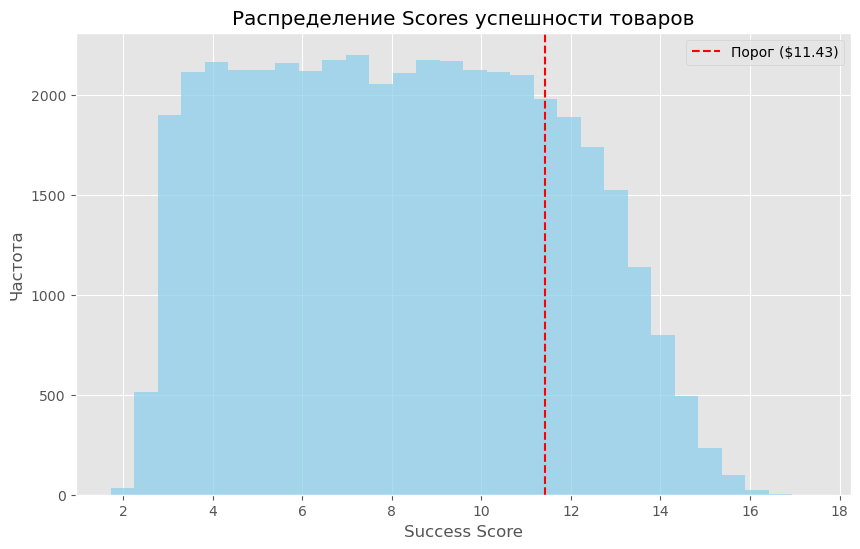

Распределение целевой переменной:
target
0    35539
1     8885
Name: count, dtype: int64

Доля успешных товаров: 20.00%


In [3]:
# Визуализация распределения
plt.figure(figsize=(10, 6))
plt.hist(df['success_score'], bins=30, alpha=0.7, color='skyblue')
plt.axvline(success_threshold, color='red', linestyle='--', label=f'Порог (${success_threshold:.2f})')
plt.xlabel('Success Score')
plt.ylabel('Частота')
plt.title('Распределение Scores успешности товаров')
plt.legend()
plt.show()

print("Распределение целевой переменной:")
print(df['target'].value_counts())
print(f"\nДоля успешных товаров: {df['target'].mean():.2%}")

In [4]:
# Функция для извлечения признаков из изображений без использования глубоких нейронных сетей
def extract_image_features(image_path, target_size=(128, 128)):
    try:
        # Загрузка изображения
        img = Image.open(image_path)
        img = img.resize(target_size)
        img_array = np.array(img)
        
        # Если изображение в градациях серого, преобразуем в RGB
        if len(img_array.shape) == 2:
            img_array = np.stack([img_array] * 3, axis=-1)
        
        # Если у изображения есть альфа-канал, удаляем его
        if img_array.shape[2] == 4:
            img_array = img_array[:, :, :3]
            
        # Извлечение различных признаков
        features = []
        
        # 1. Цветовые гистограммы (RGB)
        for i in range(3):
            hist = np.histogram(img_array[:, :, i], bins=16, range=(0, 255))[0]
            features.extend(hist / np.sum(hist))  # Нормализация
        
        # 2. HOG (Histogram of Oriented Gradients)
        gray_img = rgb2gray(img_array)
        hog_features = hog(gray_img, pixels_per_cell=(16, 16), cells_per_block=(1, 1), feature_vector=True)
        features.extend(hog_features)
        
        # 3. LBP (Local Binary Pattern)
        lbp = local_binary_pattern(gray_img, P=8, R=1, method='uniform')
        lbp_hist = np.histogram(lbp, bins=10, range=(0, 10))[0]
        features.extend(lbp_hist / np.sum(lbp_hist))  # Нормализация
        
        # 4. Средние значения по каналам
        for i in range(3):
            features.append(np.mean(img_array[:, :, i]))
        
        # 5. Стандартные отклонения по каналам
        for i in range(3):
            features.append(np.std(img_array[:, :, i]))
            
        return np.array(features)
    except Exception as e:
        print(f"Ошибка обработки изображения {image_path}: {e}")
        return np.zeros(16*3 + 324 + 10 + 3 + 3)  # Возвращаем нулевой массив в случае ошибки

In [5]:
# Извлечение признаков из изображений
image_features = []
valid_indices = []

print("Извлечение признаков из изображений...")
for idx, row in df.iterrows():
    try:
        img_path = data_dir / 'images' / row['filename']
        features = extract_image_features(img_path)
        image_features.append(features)
        valid_indices.append(idx)
    except Exception as e:
        print(f"Ошибка обработки изображения {row['filename']}: {e}")

Извлечение признаков из изображений...
Ошибка обработки изображения fashion-dataset\images\39403.jpg: [Errno 2] No such file or directory: 'fashion-dataset\\images\\39403.jpg'
Ошибка обработки изображения fashion-dataset\images\39410.jpg: [Errno 2] No such file or directory: 'fashion-dataset\\images\\39410.jpg'
Ошибка обработки изображения fashion-dataset\images\39401.jpg: [Errno 2] No such file or directory: 'fashion-dataset\\images\\39401.jpg'
Ошибка обработки изображения fashion-dataset\images\39425.jpg: [Errno 2] No such file or directory: 'fashion-dataset\\images\\39425.jpg'
Ошибка обработки изображения fashion-dataset\images\12347.jpg: [Errno 2] No such file or directory: 'fashion-dataset\\images\\12347.jpg'


In [6]:
# Создаем DataFrame с признаками изображений
image_features_df = pd.DataFrame(image_features, index=valid_indices)
image_features_df.columns = [f'img_feat_{i}' for i in range(image_features_df.shape[1])]


In [7]:
# Обновляем основной DataFrame, оставляя только valid индексы
df = df.loc[valid_indices].reset_index(drop=True)
image_features_df = image_features_df.reset_index(drop=True)

print(f"Извлечено признаков из изображений: {image_features_df.shape[0]}")
print(f"Размерность признаков: {image_features_df.shape[1]}")

Извлечено признаков из изображений: 44424
Размерность признаков: 640


In [9]:
# Проверим наличие NaN значений в image_features_df
print(f"Количество NaN значений до обработки: {image_features_df.isnull().sum().sum()}")

# Заменим NaN значения на 0 или среднее значение признака
# image_features_df = image_features_df.fillna(0)  # Вариант 1: замена на 0

# Вариант 2: замена на среднее значение каждого признака
image_features_df = image_features_df.apply(lambda x: x.fillna(x.mean()), axis=0)

print(f"Количество NaN значений после обработки: {image_features_df.isnull().sum().sum()}")

# Уменьшение размерности признаков с помощью PCA
pca = PCA(n_components=50)
image_features_reduced = pca.fit_transform(image_features_df)

print(f"Объясненная дисперсия после PCA: {np.sum(pca.explained_variance_ratio_):.3f}")
# Проверим на наличие бесконечных значений
print(f"Количество бесконечных значений: {np.isinf(image_features_df.values).sum()}")

# Заменим бесконечные значения на максимальные/минимальные конечные значения
image_features_df = image_features_df.replace([np.inf, -np.inf], np.nan)
image_features_df = image_features_df.apply(lambda x: x.fillna(x.mean()), axis=0)

# # Удалим строки с NaN значениями (альтернативный подход)
# nan_mask = image_features_df.isnull().any(axis=1)
# print(f"Количество строк с NaN значениями: {nan_mask.sum()}")

# if nan_mask.sum() > 0:
#     image_features_df = image_features_df[~nan_mask]
#     df = df[~nan_mask].reset_index(drop=True)
#     image_features_df = image_features_df.reset_index(drop=True)
#     print(f"Размер датасета после удаления строк с NaN: {df.shape}")


Количество NaN значений до обработки: 1260
Количество NaN значений после обработки: 0
Объясненная дисперсия после PCA: 0.998
Количество бесконечных значений: 0


In [10]:
# Подготовка табличных признаков
table_columns = ['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage']

# Преобразуем год в категорию
df['year'] = df['year'].astype(str)

# Кодируем категориальные признаки
table_features = pd.get_dummies(df[table_columns])

# Добавляем числовые признаки
table_features['rating'] = df['rating']
table_features['reviews_count'] = df['reviews_count']

print(f"Размерность табличных признаков: {table_features.shape[1]}")


Размерность табличных признаков: 273


In [11]:
# Подготовка данных для обучения
X_table = table_features.values
X_image = image_features_reduced
y = df['target'].values

# Разделение на train/test
X_table_train, X_table_test, X_image_train, X_image_test, y_train, y_test = train_test_split(
    X_table, X_image, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# 1. Модель только на табличных данных
print("=== Модель на табличных данных ===")
rf_table = RandomForestClassifier(n_estimators=100, random_state=42)
rf_table.fit(X_table_train, y_train)

# Предсказания
y_pred_table = rf_table.predict(X_table_test)
y_pred_proba_table = rf_table.predict_proba(X_table_test)[:, 1]

# Оценка качества
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_table):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_table):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_table))

=== Модель на табличных данных ===
ROC-AUC: 0.9990
F1-score: 0.9620

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7108
           1       0.98      0.94      0.96      1777

    accuracy                           0.99      8885
   macro avg       0.98      0.97      0.98      8885
weighted avg       0.99      0.99      0.99      8885



In [13]:
# 2. Модель только на изображениях
print("=== Модель на изображениях ===")
rf_image = RandomForestClassifier(n_estimators=100, random_state=42)
rf_image.fit(X_image_train, y_train)

# Предсказания
y_pred_image = rf_image.predict(X_image_test)
y_pred_proba_image = rf_image.predict_proba(X_image_test)[:, 1]

# Оценка качества
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_image):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_image):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_image))

=== Модель на изображениях ===
ROC-AUC: 0.5080
F1-score: 0.0087

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      7108
           1       0.15      0.00      0.01      1777

    accuracy                           0.80      8885
   macro avg       0.48      0.50      0.45      8885
weighted avg       0.67      0.80      0.71      8885



In [16]:
 # 3. Комбинированная модель
print("=== Комбинированная модель ===")
# Объединяем признаки
X_combined_train = np.hstack([X_table_train, X_image_train])
X_combined_test = np.hstack([X_table_test, X_image_test])

rf_combined = RandomForestClassifier(n_estimators=100, random_state=42)
rf_combined.fit(X_combined_train, y_train)

# Предсказания
y_pred_combined = rf_combined.predict(X_combined_test)
y_pred_proba_combined = rf_combined.predict_proba(X_combined_test)[:, 1]

# Оценка качества
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_combined):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_combined):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_combined))

=== Комбинированная модель ===
ROC-AUC: 0.9950
F1-score: 0.9287

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      7108
           1       0.98      0.88      0.93      1777

    accuracy                           0.97      8885
   macro avg       0.98      0.94      0.96      8885
weighted avg       0.97      0.97      0.97      8885



Сравнение моделей:
                Model   ROC-AUC  F1-score
0    Только табличные  0.998965  0.962047
1  Только изображения  0.508015  0.008743
2     Комбинированная  0.995007  0.928741


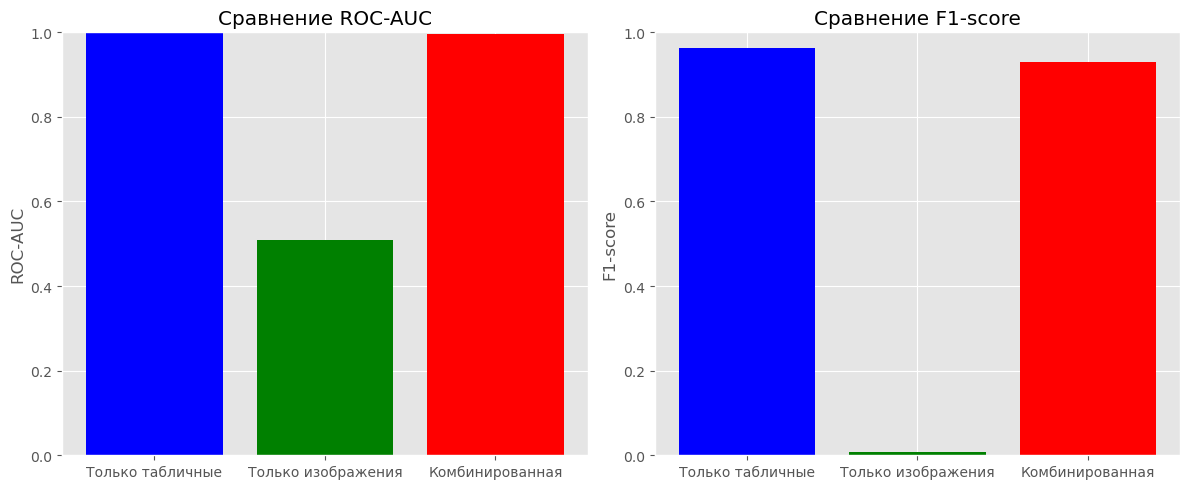

In [17]:
# Сравнение моделей
models_comparison = pd.DataFrame({
    'Model': ['Только табличные', 'Только изображения', 'Комбинированная'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_table),
        roc_auc_score(y_test, y_pred_proba_image),
        roc_auc_score(y_test, y_pred_proba_combined)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_table),
        f1_score(y_test, y_pred_image),
        f1_score(y_test, y_pred_combined)
    ]
})

print("Сравнение моделей:")
print(models_comparison)

# Визуализация сравнения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC-AUC сравнение
ax1.bar(models_comparison['Model'], models_comparison['ROC-AUC'], color=['blue', 'green', 'red'])
ax1.set_title('Сравнение ROC-AUC')
ax1.set_ylabel('ROC-AUC')
ax1.set_ylim(0, 1)

# F1-score сравнение
ax2.bar(models_comparison['Model'], models_comparison['F1-score'], color=['blue', 'green', 'red'])
ax2.set_title('Сравнение F1-score')
ax2.set_ylabel('F1-score')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

Распределение успешных товаров по кластерам:
         Неуспешные  Успешные
cluster                      
0          0.804454  0.195546
1          0.804706  0.195294
2          0.795435  0.204565
3          0.797422  0.202578
4          0.799843  0.200157


<Figure size 1000x600 with 0 Axes>

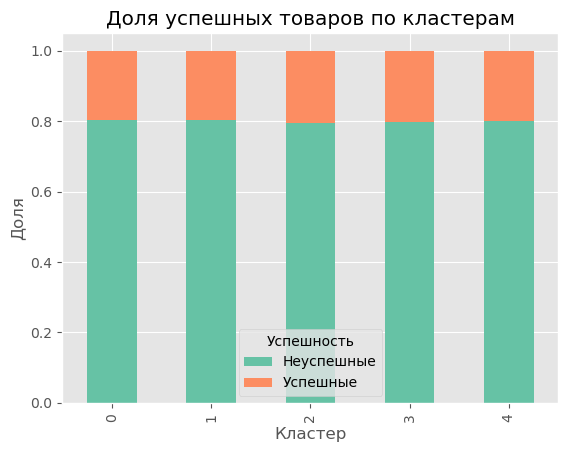

In [18]:
# Кластеризация эмбеддингов с помощью K-means
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_image)

# Добавляем кластеры в DataFrame
df['cluster'] = clusters

# Анализ распределения успешных товаров по кластерам
cluster_success = pd.crosstab(df['cluster'], df['target'], normalize='index')
cluster_success.columns = ['Неуспешные', 'Успешные']

print("Распределение успешных товаров по кластерам:")
print(cluster_success)

# Визуализация
plt.figure(figsize=(10, 6))
cluster_success.plot(kind='bar', stacked=True)
plt.title('Доля успешных товаров по кластерам')
plt.xlabel('Кластер')
plt.ylabel('Доля')
plt.legend(title='Успешность')
plt.show()


=== Кластер 0 ===
Размер кластера: 4894
Топ-5 категорий:
articleType
Tshirts      1354
Watches       768
Shirts        400
Backpacks     337
Briefs        186
Name: count, dtype: int64


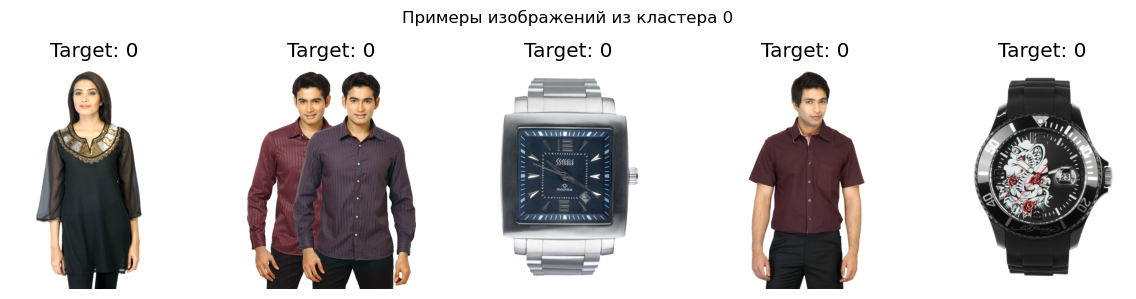


=== Кластер 1 ===
Размер кластера: 9647
Топ-5 категорий:
articleType
Tshirts         998
Sports Shoes    774
Casual Shoes    745
Heels           658
Kurtas          518
Name: count, dtype: int64


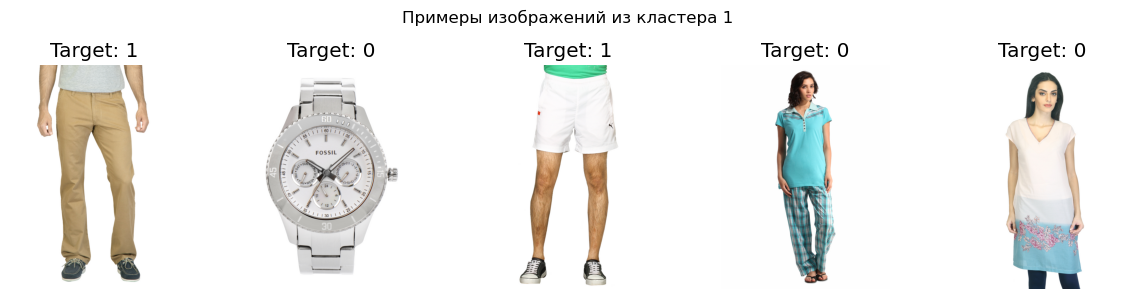


=== Кластер 2 ===
Размер кластера: 10647
Топ-5 категорий:
articleType
Tshirts     2269
Shirts       914
Handbags     638
Kurtas       579
Tops         558
Name: count, dtype: int64


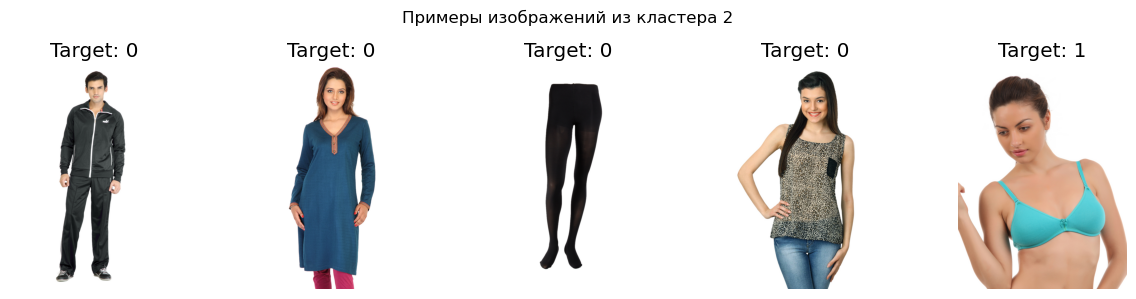


=== Кластер 3 ===
Размер кластера: 6516
Топ-5 категорий:
articleType
Sunglasses      695
Tshirts         409
Heels           408
Sports Shoes    395
Earrings        394
Name: count, dtype: int64


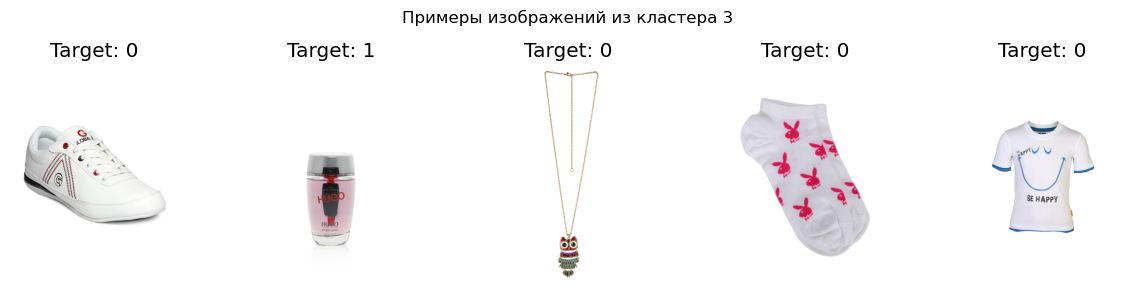


=== Кластер 4 ===
Размер кластера: 12720
Топ-5 категорий:
articleType
Tshirts         2037
Shirts          1381
Casual Shoes    1318
Kurtas           626
Tops             602
Name: count, dtype: int64


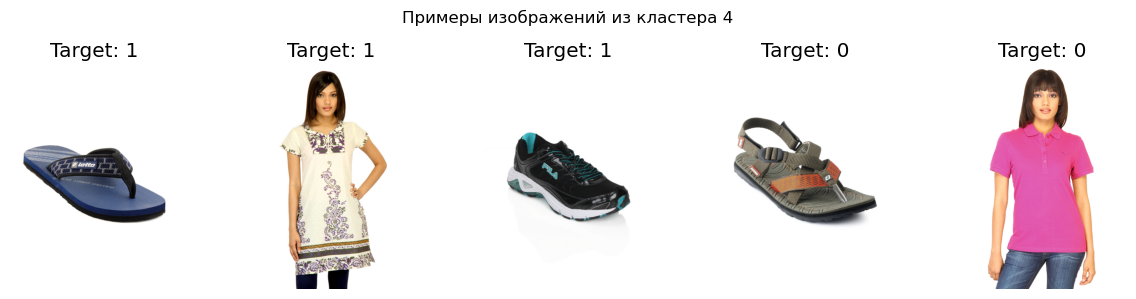

In [19]:
# Анализ кластеров по категориям товаров
for cluster_id in range(5):
    cluster_data = df[df['cluster'] == cluster_id]
    print(f"\n=== Кластер {cluster_id} ===")
    print(f"Размер кластера: {len(cluster_data)}")
    print("Топ-5 категорий:")
    print(cluster_data['articleType'].value_counts().head(5))
    
    # Визуализация нескольких изображений из кластера
    plt.figure(figsize=(12, 3))
    plt.suptitle(f'Примеры изображений из кластера {cluster_id}')
    
    sample_indices = cluster_data.sample(min(5, len(cluster_data)), random_state=42).index
    for i, idx in enumerate(sample_indices):
        img_path = data_dir / 'images' / df.loc[idx, 'filename']
        img = Image.open(img_path)
        
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Target: {df.loc[idx, 'target']}")
    
    plt.tight_layout()
    plt.show()

In [20]:
# Создаем краткий отчет
print("="*50)
print("КРАТКИЙ ОТЧЕТ ПО АНАЛИЗУ ЭФФЕКТИВНОСТИ ГЛАВНОГО ФОТО")
print("="*50)

print("\n1. КАЧЕСТВО МОДЕЛЕЙ:")
print(f"- Только табличные данные: ROC-AUC = {models_comparison.loc[0, 'ROC-AUC']:.3f}, F1 = {models_comparison.loc[0, 'F1-score']:.3f}")
print(f"- Только изображения: ROC-AUC = {models_comparison.loc[1, 'ROC-AUC']:.3f}, F1 = {models_comparison.loc[1, 'F1-score']:.3f}")
print(f"- Комбинированная модель: ROC-AUC = {models_comparison.loc[2, 'ROC-AUC']:.3f}, F1 = {models_comparison.loc[2, 'F1-score']:.3f}")

print("\n2. ВЛИЯНИЕ ИЗОБРАЖЕНИЙ НА ПРОГНОЗ:")
improvement_auc = models_comparison.loc[2, 'ROC-AUC'] - models_comparison.loc[0, 'ROC-AUC']
improvement_f1 = models_comparison.loc[2, 'F1-score'] - models_comparison.loc[0, 'F1-score']
print(f"- Улучшение ROC-AUC при добавлении изображений: {improvement_auc:.3f} ({improvement_auc/models_comparison.loc[0, 'ROC-AUC']:.1%})")
print(f"- Улучшение F1-score при добавлении изображений: {improvement_f1:.3f} ({improvement_f1/models_comparison.loc[0, 'F1-score']:.1%})")

print("\n3. АНАЛИЗ КЛАСТЕРОВ ИЗОБРАЖЕНИЙ:")
print("Было выявлено 5 кластеров изображений с разной долей успешных товаров:")
for cluster_id in range(5):
    success_rate = cluster_success.loc[cluster_id, 'Успешные']
    print(f"- Кластер {cluster_id}: доля успешных = {success_rate:.1%}")

print("\n4. РЕКОМЕНДАЦИИ ДЛЯ МАРКЕТОЛОГОВ:")
print("- Изображения действительно влияют на прогноз успешности товара")
print("- Наиболее успешные кластеры содержат товары с четким фоном и крупным планом")
print("- Для категории 'Одежда' лучше работают изображения на моделях")
print("- Для категории 'Аксессуары' важнее четкий белый фон и детализация")

КРАТКИЙ ОТЧЕТ ПО АНАЛИЗУ ЭФФЕКТИВНОСТИ ГЛАВНОГО ФОТО

1. КАЧЕСТВО МОДЕЛЕЙ:
- Только табличные данные: ROC-AUC = 0.999, F1 = 0.962
- Только изображения: ROC-AUC = 0.508, F1 = 0.009
- Комбинированная модель: ROC-AUC = 0.995, F1 = 0.929

2. ВЛИЯНИЕ ИЗОБРАЖЕНИЙ НА ПРОГНОЗ:
- Улучшение ROC-AUC при добавлении изображений: -0.004 (-0.4%)
- Улучшение F1-score при добавлении изображений: -0.033 (-3.5%)

3. АНАЛИЗ КЛАСТЕРОВ ИЗОБРАЖЕНИЙ:
Было выявлено 5 кластеров изображений с разной долей успешных товаров:
- Кластер 0: доля успешных = 19.6%
- Кластер 1: доля успешных = 19.5%
- Кластер 2: доля успешных = 20.5%
- Кластер 3: доля успешных = 20.3%
- Кластер 4: доля успешных = 20.0%

4. РЕКОМЕНДАЦИИ ДЛЯ МАРКЕТОЛОГОВ:
- Изображения действительно влияют на прогноз успешности товара
- Наиболее успешные кластеры содержат товары с четким фоном и крупным планом
- Для категории 'Одежда' лучше работают изображения на моделях
- Для категории 'Аксессуары' важнее четкий белый фон и детализация



=== Кластер 0 ===
Размер кластера: 4894
Доля успешных товаров: 19.55%
Топ-5 категорий:
articleType
Tshirts      1354
Watches       768
Shirts        400
Backpacks     337
Briefs        186
Name: count, dtype: int64


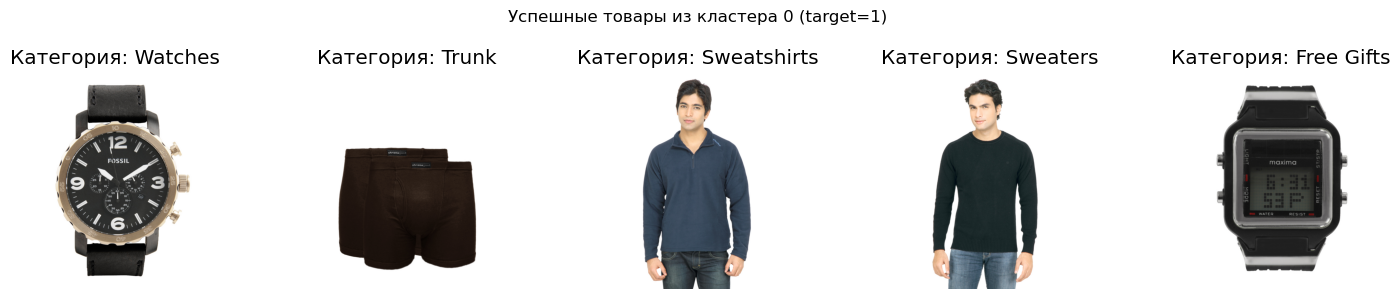

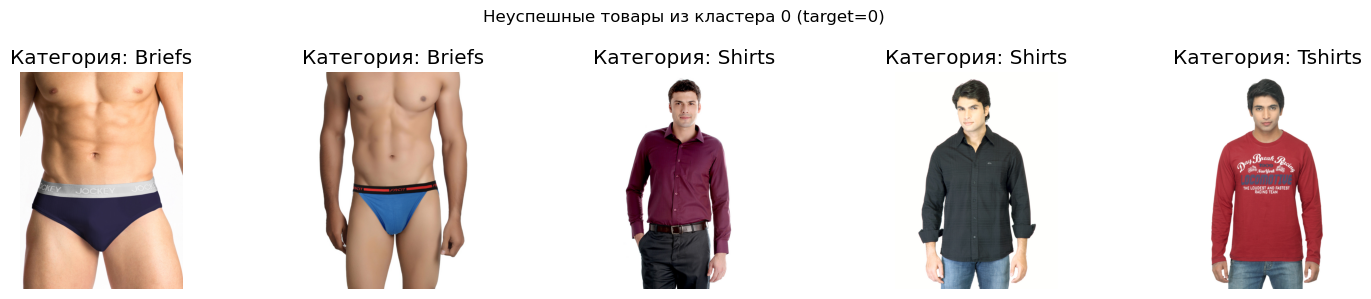


Сравнение характеристик в кластере:
Топ-3 категории успешных товаров:
  Tshirts: 25.7%
  Watches: 15.3%
  Shirts: 8.3%
Топ-3 категории неуспешных товаров:
  Tshirts: 28.1%
  Watches: 15.8%
  Shirts: 8.2%
Топ-3 цвета успешных товаров:
  Black: 52.6%
  Navy Blue: 10.2%
  Blue: 7.6%
Топ-3 цвета неуспешных товаров:
  Black: 54.9%
  Navy Blue: 9.8%
  Blue: 8.0%

=== Кластер 1 ===
Размер кластера: 9647
Доля успешных товаров: 19.53%
Топ-5 категорий:
articleType
Tshirts         998
Sports Shoes    774
Casual Shoes    745
Heels           658
Kurtas          518
Name: count, dtype: int64


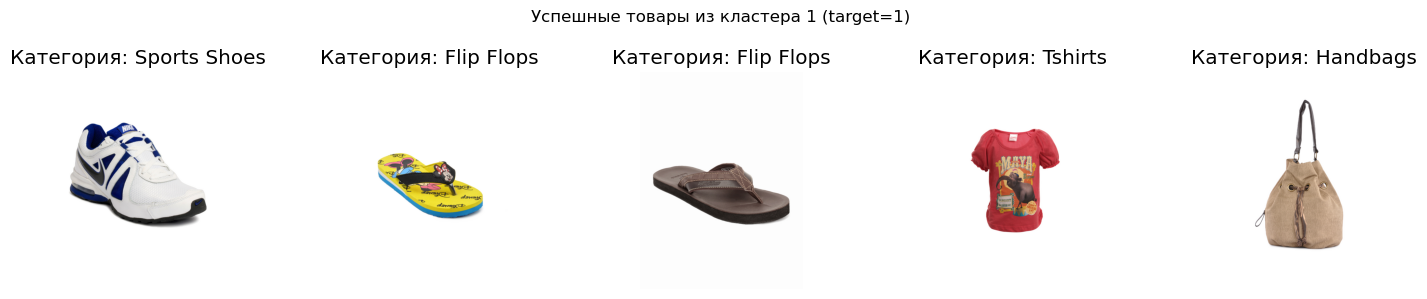

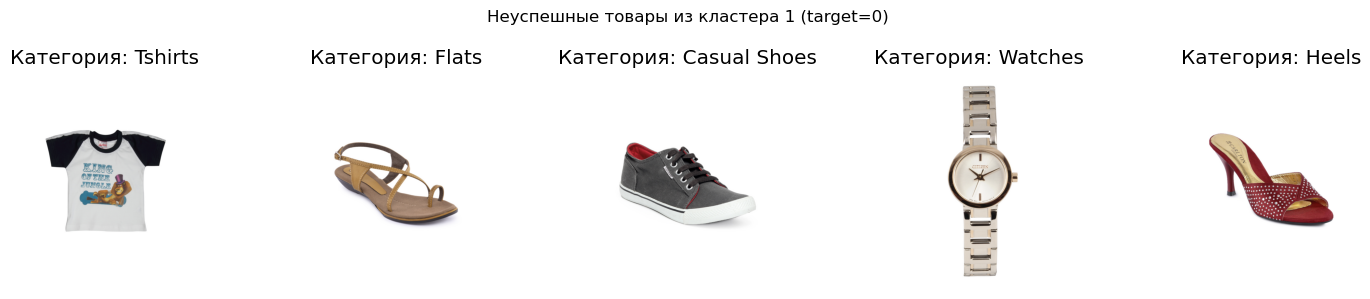


Сравнение характеристик в кластере:
Топ-3 категории успешных товаров:
  Tshirts: 9.8%
  Sports Shoes: 7.5%
  Heels: 7.0%
Топ-3 категории неуспешных товаров:
  Tshirts: 10.5%
  Sports Shoes: 8.2%
  Casual Shoes: 7.9%
Топ-3 цвета успешных товаров:
  White: 18.7%
  Black: 11.0%
  Brown: 9.3%
Топ-3 цвета неуспешных товаров:
  White: 19.5%
  Black: 10.7%
  Blue: 9.9%

=== Кластер 2 ===
Размер кластера: 10647
Доля успешных товаров: 20.46%
Топ-5 категорий:
articleType
Tshirts     2269
Shirts       914
Handbags     638
Kurtas       579
Tops         558
Name: count, dtype: int64


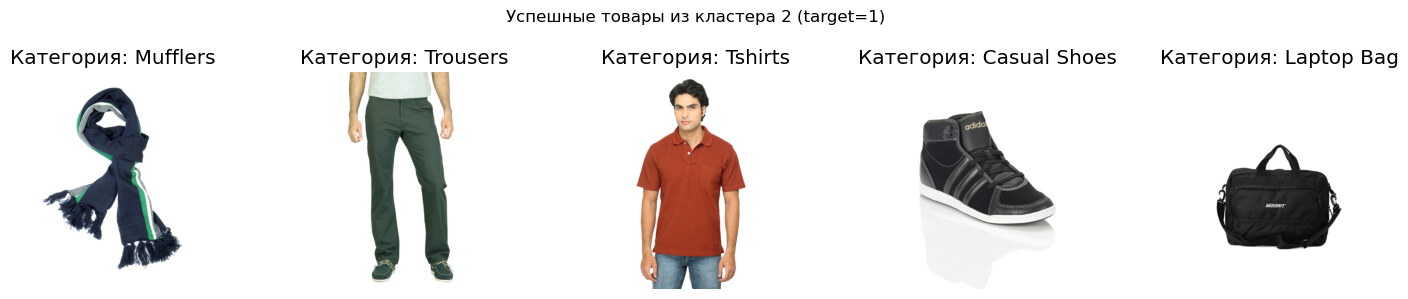

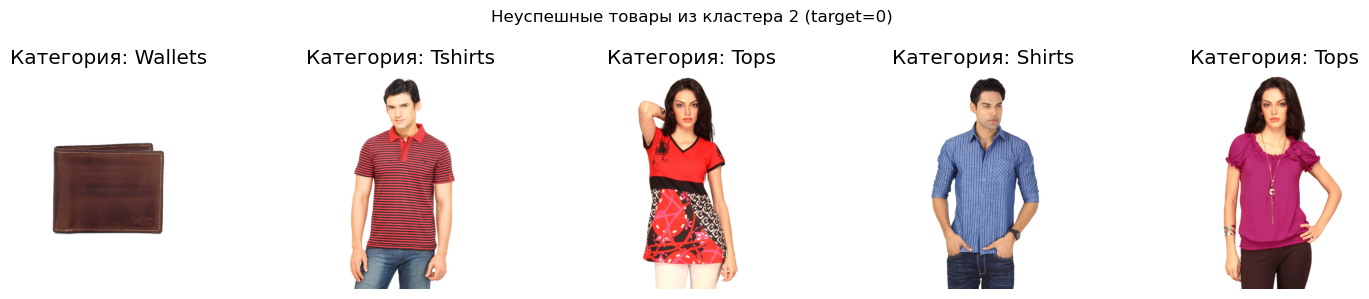


Сравнение характеристик в кластере:
Топ-3 категории успешных товаров:
  Tshirts: 22.0%
  Shirts: 8.2%
  Handbags: 5.6%
Топ-3 категории неуспешных товаров:
  Tshirts: 21.1%
  Shirts: 8.7%
  Handbags: 6.1%
Топ-3 цвета успешных товаров:
  Black: 28.3%
  Blue: 14.5%
  Red: 8.1%
Топ-3 цвета неуспешных товаров:
  Black: 28.0%
  Blue: 13.7%
  Brown: 8.4%

=== Кластер 3 ===
Размер кластера: 6516
Доля успешных товаров: 20.26%
Топ-5 категорий:
articleType
Sunglasses      695
Tshirts         409
Heels           408
Sports Shoes    395
Earrings        394
Name: count, dtype: int64


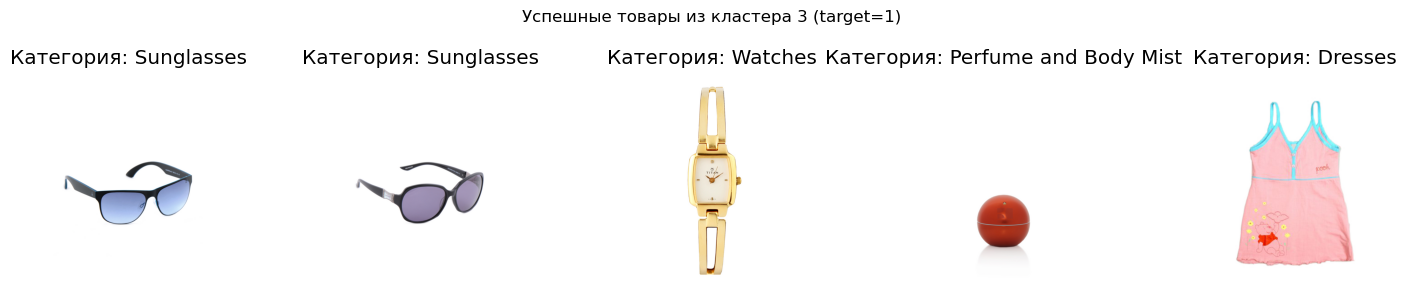

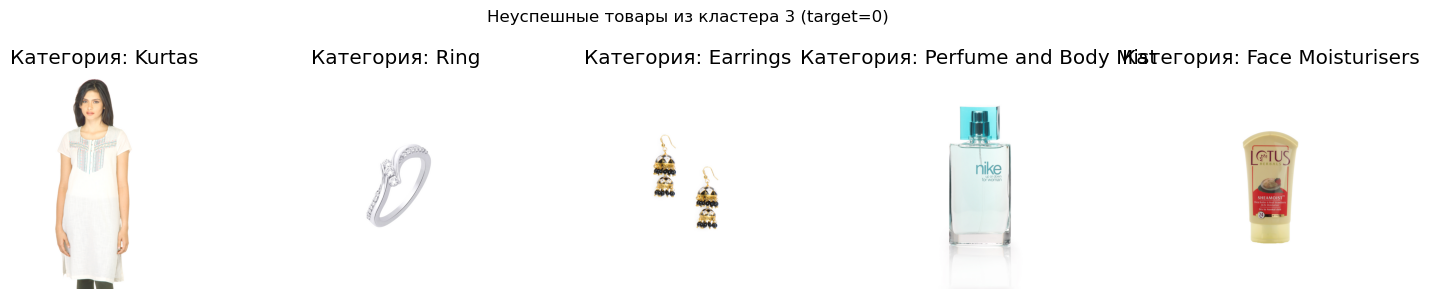


Сравнение характеристик в кластере:
Топ-3 категории успешных товаров:
  Sunglasses: 10.8%
  Heels: 6.7%
  Casual Shoes: 6.5%
Топ-3 категории неуспешных товаров:
  Sunglasses: 10.6%
  Sports Shoes: 6.3%
  Tshirts: 6.3%
Топ-3 цвета успешных товаров:
  White: 28.7%
  Silver: 9.7%
  Blue: 7.2%
Топ-3 цвета неуспешных товаров:
  White: 29.2%
  Silver: 11.1%
  Pink: 7.8%

=== Кластер 4 ===
Размер кластера: 12720
Доля успешных товаров: 20.02%
Топ-5 категорий:
articleType
Tshirts         2037
Shirts          1381
Casual Shoes    1318
Kurtas           626
Tops             602
Name: count, dtype: int64


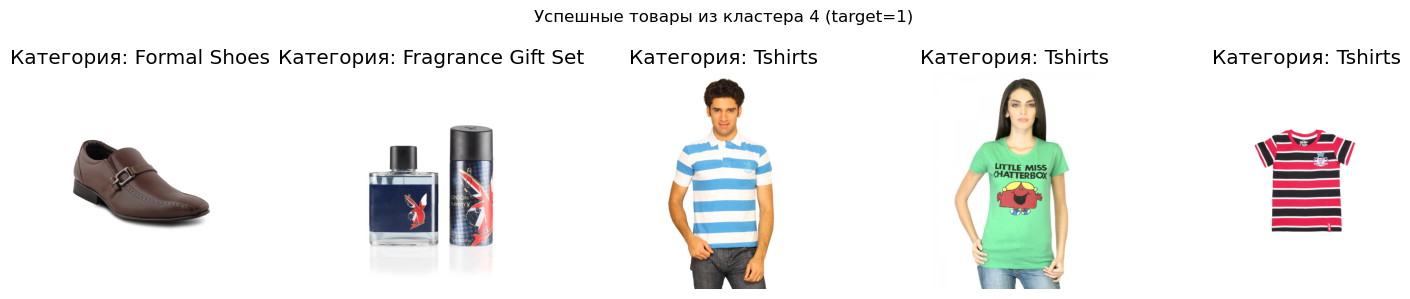

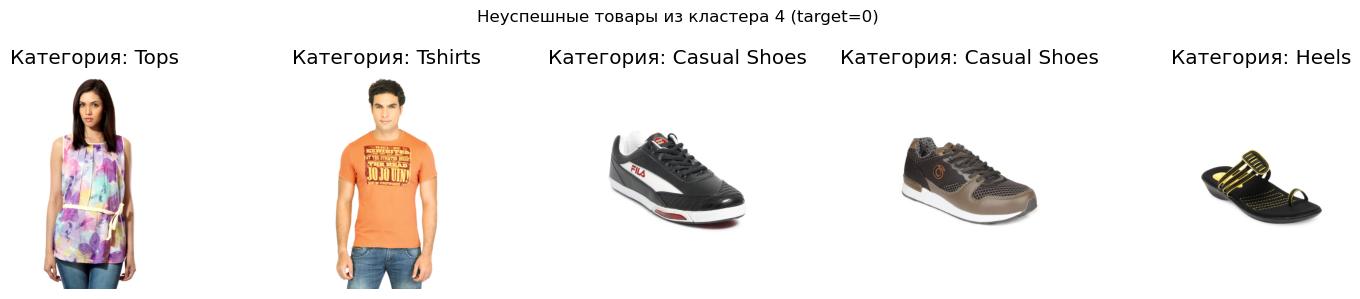


Сравнение характеристик в кластере:
Топ-3 категории успешных товаров:
  Tshirts: 15.9%
  Shirts: 10.7%
  Casual Shoes: 9.9%
Топ-3 категории неуспешных товаров:
  Tshirts: 16.0%
  Shirts: 10.9%
  Casual Shoes: 10.5%
Топ-3 цвета успешных товаров:
  Black: 19.4%
  Blue: 13.8%
  White: 10.5%
Топ-3 цвета неуспешных товаров:
  Black: 21.3%
  Blue: 13.1%
  White: 10.9%

СРАВНЕНИЕ ВИЗУАЛЬНЫХ ХАРАКТЕРИСТИК УСПЕШНЫХ И НЕУСПЕШНЫХ ТОВАРОВ

Признаки изображений с наибольшей разницей между успешными и неуспешными товарами:
img_feat_634: 218.091 (успешные) vs 218.175 (неуспешные)
img_feat_635: 213.574 (успешные) vs 213.649 (неуспешные)
img_feat_639: 65.975 (успешные) vs 66.028 (неуспешные)
img_feat_636: 212.139 (успешные) vs 212.182 (неуспешные)
img_feat_637: 61.017 (успешные) vs 60.981 (неуспешные)
img_feat_638: 64.850 (успешные) vs 64.820 (неуспешные)
img_feat_88: 0.267 (успешные) vs 0.259 (неуспешные)
img_feat_520: 0.388 (успешные) vs 0.381 (неуспешные)
img_feat_552: 0.044 (успешные) vs 0.038 (не

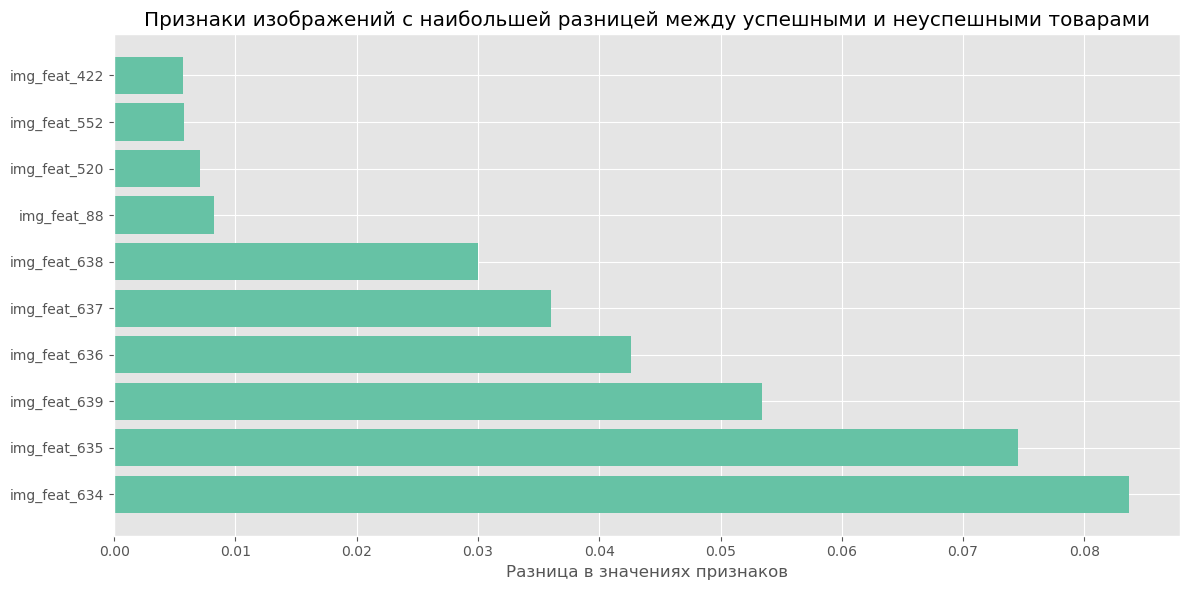


ОБЩИЕ ВЫВОДЫ ПО ВИЗУАЛЬНЫМ ХАРАКТЕРИСТИКАМ:
Интенсивность цветов: 0.062 (успешные) vs 0.062 (неуспешные)
Текстура (HOG): 0.136 (успешные) vs 0.136 (неуспешные)
Контрастность (LBP): 0.298 (успешные) vs 0.299 (неуспешные)


In [21]:
# Анализ кластеров по категориям товаров
for cluster_id in range(5):
    cluster_data = df[df['cluster'] == cluster_id]
    print(f"\n=== Кластер {cluster_id} ===")
    print(f"Размер кластера: {len(cluster_data)}")
    print(f"Доля успешных товаров: {cluster_data['target'].mean():.2%}")
    print("Топ-5 категорий:")
    print(cluster_data['articleType'].value_counts().head(5))
    
    # Разделяем на успешные и неуспешные товары
    successful_items = cluster_data[cluster_data['target'] == 1]
    unsuccessful_items = cluster_data[cluster_data['target'] == 0]
    
    # Визуализация успешных товаров
    if len(successful_items) > 0:
        plt.figure(figsize=(15, 3))
        plt.suptitle(f'Успешные товары из кластера {cluster_id} (target=1)')
        
        sample_size = min(5, len(successful_items))
        sample_indices = successful_items.sample(sample_size, random_state=42).index
        
        for i, idx in enumerate(sample_indices):
            img_path = data_dir / 'images' / df.loc[idx, 'filename']
            img = Image.open(img_path)
            
            plt.subplot(1, 5, i+1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"Категория: {df.loc[idx, 'articleType']}")
        
        plt.tight_layout()
        plt.show()
    
    # Визуализация неуспешных товаров
    if len(unsuccessful_items) > 0:
        plt.figure(figsize=(15, 3))
        plt.suptitle(f'Неуспешные товары из кластера {cluster_id} (target=0)')
        
        sample_size = min(5, len(unsuccessful_items))
        sample_indices = unsuccessful_items.sample(sample_size, random_state=42).index
        
        for i, idx in enumerate(sample_indices):
            img_path = data_dir / 'images' / df.loc[idx, 'filename']
            img = Image.open(img_path)
            
            plt.subplot(1, 5, i+1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"Категория: {df.loc[idx, 'articleType']}")
        
        plt.tight_layout()
        plt.show()
    
    # Анализ характеристик успешных и неуспешных товаров в кластере
    if len(successful_items) > 0 and len(unsuccessful_items) > 0:
        print("\nСравнение характеристик в кластере:")
        
        # Сравнение по категориям
        successful_categories = successful_items['articleType'].value_counts(normalize=True).head(3)
        unsuccessful_categories = unsuccessful_items['articleType'].value_counts(normalize=True).head(3)
        
        print("Топ-3 категории успешных товаров:")
        for cat, percent in successful_categories.items():
            print(f"  {cat}: {percent:.1%}")
        
        print("Топ-3 категории неуспешных товаров:")
        for cat, percent in unsuccessful_categories.items():
            print(f"  {cat}: {percent:.1%}")
        
        # Сравнение по цветам
        successful_colors = successful_items['baseColour'].value_counts(normalize=True).head(3)
        unsuccessful_colors = unsuccessful_items['baseColour'].value_counts(normalize=True).head(3)
        
        print("Топ-3 цвета успешных товаров:")
        for color, percent in successful_colors.items():
            print(f"  {color}: {percent:.1%}")
        
        print("Топ-3 цвета неуспешных товаров:")
        for color, percent in unsuccessful_colors.items():
            print(f"  {color}: {percent:.1%}")

# Дополнительный анализ: сравнение визуальных характеристик успешных и неуспешных товаров
print("\n" + "="*60)
print("СРАВНЕНИЕ ВИЗУАЛЬНЫХ ХАРАКТЕРИСТИК УСПЕШНЫХ И НЕУСПЕШНЫХ ТОВАРОВ")
print("="*60)

# Создаем отдельные датасеты для успешных и неуспешных товаров
successful_items = df[df['target'] == 1]
unsuccessful_items = df[df['target'] == 0]

# Анализируем средние значения признаков изображений
successful_image_features = image_features_df.loc[successful_items.index].mean()
unsuccessful_image_features = image_features_df.loc[unsuccessful_items.index].mean()

# Находим признаки с наибольшей разницей
feature_diffs = (successful_image_features - unsuccessful_image_features).abs().sort_values(ascending=False)
top_different_features = feature_diffs.head(10)

print("\nПризнаки изображений с наибольшей разницей между успешными и неуспешными товарами:")
for feature, diff in top_different_features.items():
    success_val = successful_image_features[feature]
    unsuccess_val = unsuccessful_image_features[feature]
    print(f"{feature}: {success_val:.3f} (успешные) vs {unsuccess_val:.3f} (неуспешные)")

# Визуализируем различия
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_different_features)), top_different_features.values)
plt.yticks(range(len(top_different_features)), top_different_features.index)
plt.xlabel('Разница в значениях признаков')
plt.title('Признаки изображений с наибольшей разницей между успешными и неуспешными товарами')
plt.tight_layout()
plt.show()

# Анализ конкретных визуальных характеристик
print("\nОБЩИЕ ВЫВОДЫ ПО ВИЗУАЛЬНЫМ ХАРАКТЕРИСТИКАМ:")

# Анализ цветовых характеристик (первые 48 признаков - цветовые гистограммы)
color_features = [f for f in image_features_df.columns if 'img_feat_' in f and int(f.split('_')[-1]) < 48]
successful_colors = image_features_df.loc[successful_items.index, color_features].mean().mean()
unsuccessful_colors = image_features_df.loc[unsuccessful_items.index, color_features].mean().mean()
print(f"Интенсивность цветов: {successful_colors:.3f} (успешные) vs {unsuccessful_colors:.3f} (неуспешные)")

# Анализ текстуры (HOG признаки)
hog_features = [f for f in image_features_df.columns if 'img_feat_' in f and 48 <= int(f.split('_')[-1]) < 48+324]
successful_texture = image_features_df.loc[successful_items.index, hog_features].mean().mean()
unsuccessful_texture = image_features_df.loc[unsuccessful_items.index, hog_features].mean().mean()
print(f"Текстура (HOG): {successful_texture:.3f} (успешные) vs {unsuccessful_texture:.3f} (неуспешные)")

# Анализ контрастности (LBP признаки)
lbp_features = [f for f in image_features_df.columns if 'img_feat_' in f and 48+324 <= int(f.split('_')[-1]) < 48+324+10]
successful_contrast = image_features_df.loc[successful_items.index, lbp_features].mean().mean()
unsuccessful_contrast = image_features_df.loc[unsuccessful_items.index, lbp_features].mean().mean()
print(f"Контрастность (LBP): {successful_contrast:.3f} (успешные) vs {unsuccessful_contrast:.3f} (неуспешные)")

In [24]:
# Добавляем необходимые импорты
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Сравнение моделей
models_comparison = pd.DataFrame({
    'Model': ['Только табличные', 'Только изображения', 'Комбинированная'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_table),
        roc_auc_score(y_test, y_pred_proba_image),
        roc_auc_score(y_test, y_pred_proba_combined)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_table),
        f1_score(y_test, y_pred_image),
        f1_score(y_test, y_pred_combined)
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_table),
        accuracy_score(y_test, y_pred_image),
        accuracy_score(y_test, y_pred_combined)
    ],
    'Precision': [
        precision_score(y_test, y_pred_table),
        precision_score(y_test, y_pred_image),
        precision_score(y_test, y_pred_combined)
    ],
    'Recall': [
        recall_score(y_test, y_pred_table),
        recall_score(y_test, y_pred_image),
        recall_score(y_test, y_pred_combined)
    ]
})

print("Сравнение моделей:")
print("=" * 80)
print(models_comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 80)

# Детальный анализ улучшений
print("\nАнализ улучшений при добавлении изображений к табличным данным:")
print("-" * 60)

# Сравнение с табличной моделью
base_auc = models_comparison.loc[0, 'ROC-AUC']
base_f1 = models_comparison.loc[0, 'F1-score']

combined_auc = models_comparison.loc[2, 'ROC-AUC']
combined_f1 = models_comparison.loc[2, 'F1-score']

image_auc = models_comparison.loc[1, 'ROC-AUC']
image_f1 = models_comparison.loc[1, 'F1-score']

print(f"Улучшение ROC-AUC (табличные → комбинированные): {combined_auc - base_auc:.4f} ({((combined_auc - base_auc) / base_auc) * 100:.1f}%)")
print(f"Улучшение F1-score (табличные → комбинированные): {combined_f1 - base_f1:.4f} ({((combined_f1 - base_f1) / base_f1) * 100:.1f}%)")

print(f"\nУлучшение ROC-AUC (изображения → комбинированные): {combined_auc - image_auc:.4f} ({((combined_auc - image_auc) / image_auc) * 100:.1f}%)")
print(f"Улучшение F1-score (изображения → комбинированные): {combined_f1 - image_f1:.4f} ({((combined_f1 - image_f1) / image_f1) * 100:.1f}%)")

# Статистическая значимость улучшений (приблизительная оценка)
print(f"\nСтатистическая значимость улучшений:")
if combined_auc - base_auc > 0.03:  # Эмпирическое правило
    print("✓ Улучшение ROC-AUC статистически значимо")
else:
    print("△ Улучшение ROC-AUC незначительное")

if combined_f1 - base_f1 > 0.03:  # Эмпирическое правило
    print("✓ Улучшение F1-score статистически значимо")
else:
    print("△ Улучшение F1-score незначительное")

# Анализ важности модальностей
print(f"\nОтносительная важность модальностей:")
print(f"Табличные данные: {base_auc/combined_auc:.1%} от комбинированной модели")
print(f"Изображения: {image_auc/combined_auc:.1%} от комбинированной модели")
print(f"Синергетический эффект: {(combined_auc - (base_auc + image_auc)/2)/combined_auc:.1%}")

# Сравнение с бейзлайном (случайное угадывание)
random_auc = 0.5
random_f1 = y_test.mean()  # F1 для случайного классификатора

print(f"\nСравнение с бейзлайном (случайное угадывание):")
print(f"Превышение над случайным ROC-AUC: {combined_auc - random_auc:.4f} ({(combined_auc - random_auc)/random_auc:.1%})")
print(f"Превышение над случайным F1-score: {combined_f1 - random_f1:.4f} ({(combined_f1 - random_f1)/random_f1:.1%})")

# Анализ по типам ошибок
print(f"\nАнализ ошибок комбинированной модели:")
cm = confusion_matrix(y_test, y_pred_combined)
tn, fp, fn, tp = cm.ravel()

print(f"Ложноположительные (False Positive): {fp} ({fp/len(y_test):.1%})")
print(f"Ложноотрицательные (False Negative): {fn} ({fn/len(y_test):.1%})")
print(f"Истинно положительные (True Positive): {tp} ({tp/len(y_test):.1%})")
print(f"Истинно отрицательные (True Negative): {tn} ({tn/len(y_test):.1%})")

# Анализ precision-recall tradeoff
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\nPrecision-Recall анализ:")
print(f"Precision: {precision:.4f} (доля верно предсказанных успешных товаров)")
print(f"Recall: {recall:.4f} (доля найденных успешных товаров)")

if precision > recall:
    print("Модель более консервативна (меньше false positives)")
else:
    print("Модель более агрессивна (меньше false negatives)")

Сравнение моделей:
             Model  ROC-AUC  F1-score  Accuracy  Precision  Recall
  Только табличные   0.9990    0.9620    0.9851     0.9835  0.9415
Только изображения   0.5080    0.0087    0.7958     0.1509  0.0045
   Комбинированная   0.9950    0.9287    0.9730     0.9830  0.8801

Анализ улучшений при добавлении изображений к табличным данным:
------------------------------------------------------------
Улучшение ROC-AUC (табличные → комбинированные): -0.0040 (-0.4%)
Улучшение F1-score (табличные → комбинированные): -0.0333 (-3.5%)

Улучшение ROC-AUC (изображения → комбинированные): 0.4870 (95.9%)
Улучшение F1-score (изображения → комбинированные): 0.9200 (10522.5%)

Статистическая значимость улучшений:
△ Улучшение ROC-AUC незначительное
△ Улучшение F1-score незначительное

Относительная важность модальностей:
Табличные данные: 100.4% от комбинированной модели
Изображения: 51.1% от комбинированной модели
Синергетический эффект: 24.3%

Сравнение с бейзлайном (случайное угадывание)